In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [5]:
df = pd.read_csv("../data/cleaned/superstore_final.csv")

In [9]:
print("Shape:", df.shape)

df.head()

Shape: (10194, 26)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Quarter,Shipping Days,Profit Margin
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,January,1,4,33.75
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,January,1,4,-155.00
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Avery 508,11.784,3,0.2,4.2717,2023,January,1,4,36.25
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,January,1,4,-23.75
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,January,1,7,25.00


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [11]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit,Order Year,Quarter,Shipping Days,Profit Margin
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417,2024.720129,2.882676,3.961350,12.221784
std,2942.898656,619.906839,2.228317,0.206249,232.465115,1.125611,1.060316,1.742829,46.488992
min,1.000000,0.444000,1.000000,0.000000,-6599.978000,2023.000000,1.000000,0.000000,-275.000000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800,2024.000000,2.000000,3.000000,7.500000
50%,5097.500000,53.910000,3.000000,0.200000,8.690000,2025.000000,3.000000,4.000000,27.000000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925,2026.000000,4.000000,5.000000,36.250000
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000,2026.000000,4.000000,11.000000,50.000000


In [12]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year', 'Order Month', 'Quarter', 'Shipping Days', 'Profit Margin']


Analysis 1 — Monthly Sales Trend

In [13]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = (
    df.groupby("Order Month")["Sales"]
    .sum()
    .reindex(month_order)
    .reset_index()
)

monthly_sales

,Order Month,Sales
0,January,96069.5156
1,February,59751.2514
2,March,210672.0868
3,April,138098.7486
4,May,158765.0337
5,June,153459.9973
6,July,149001.7130
7,August,161821.9150
8,September,308883.6697
9,October,207126.2567


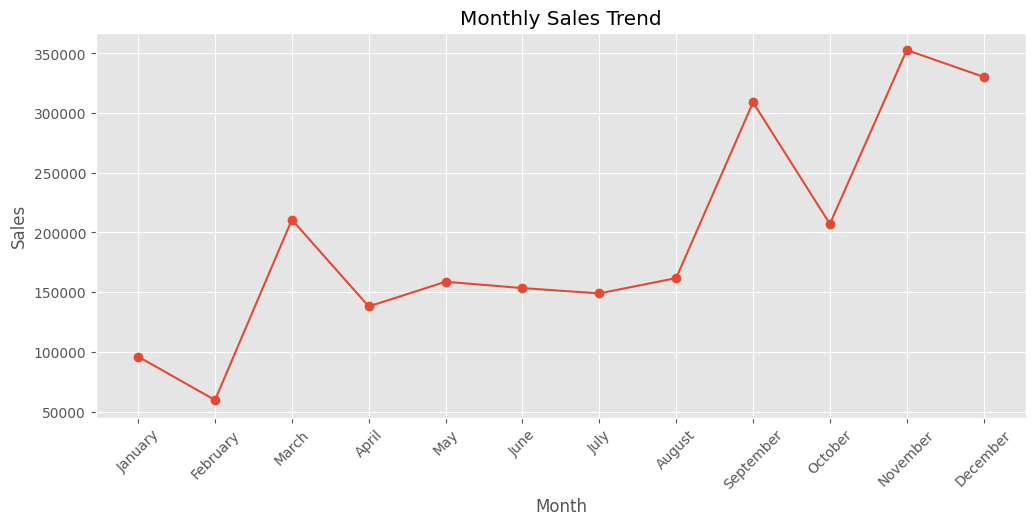

In [14]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Order Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

Analysis 2 — Sales by Category

In [15]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

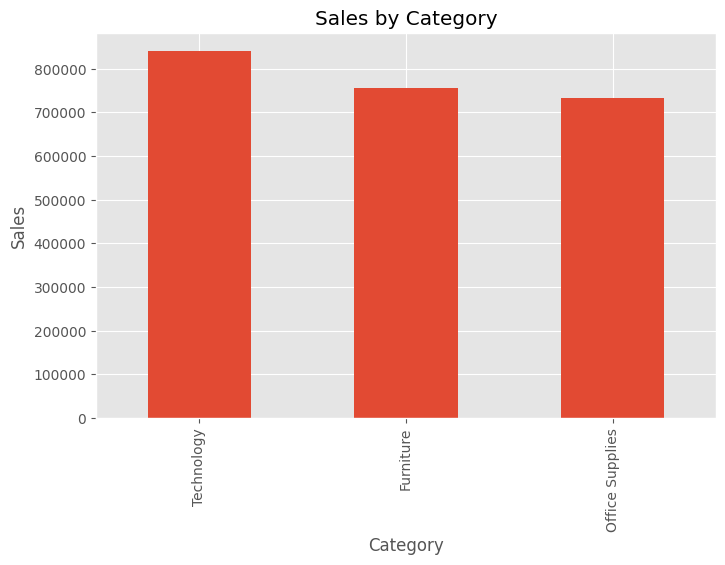

In [16]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.ylabel("Sales")

plt.show()

Analysis 3 — Profit by Category

In [17]:
profit_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_category

Category
Technology         146543.3756
Office Supplies    126023.4434
Furniture           19729.9956
Name: Profit, dtype: float64

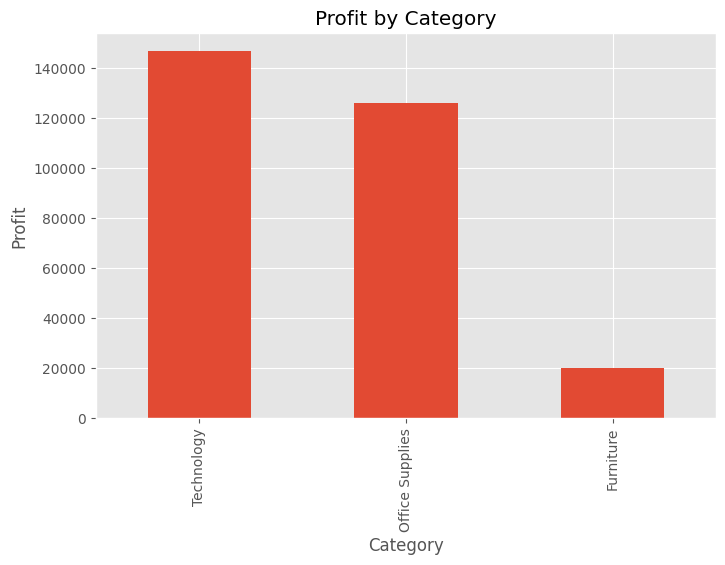

In [18]:
plt.figure(figsize=(8,5))

profit_category.plot(kind="bar")

plt.title("Profit by Category")
plt.ylabel("Profit")

plt.show()

Analysis 4 — Sales by Region

In [19]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
West       739813.6085
East       691828.1680
Central    503170.6728
South      391721.9050
Name: Sales, dtype: float64

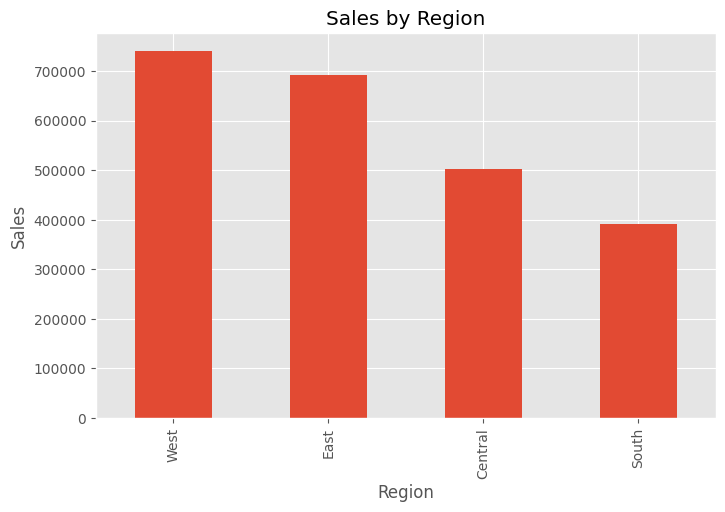

In [20]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.ylabel("Sales")

plt.show()

Analysis 5 — Profit by Region

In [21]:
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

region_profit

Region
West       110798.8170
East        94883.2603
South       46749.4303
Central     39865.3070
Name: Profit, dtype: float64

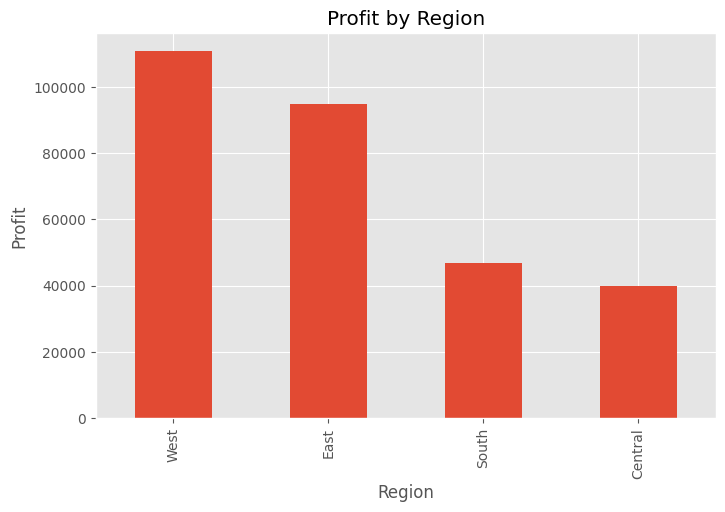

In [22]:
plt.figure(figsize=(8,5))

region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.ylabel("Profit")

plt.show()

Analysis 6 — Sales by Customer Segment

In [23]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       1.170660e+06
Corporate      7.158061e+05
Home Office    4.400684e+05
Name: Sales, dtype: float64

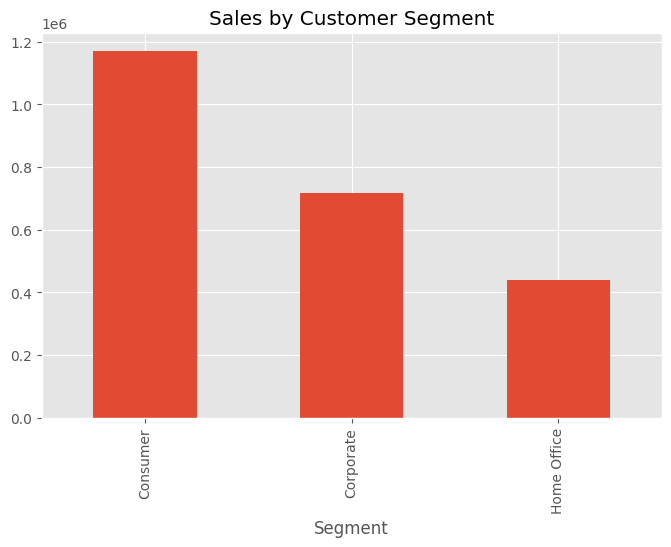

In [24]:
plt.figure(figsize=(8,5))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")

plt.show()

Analysis 7 — Top 10 Customers

In [25]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

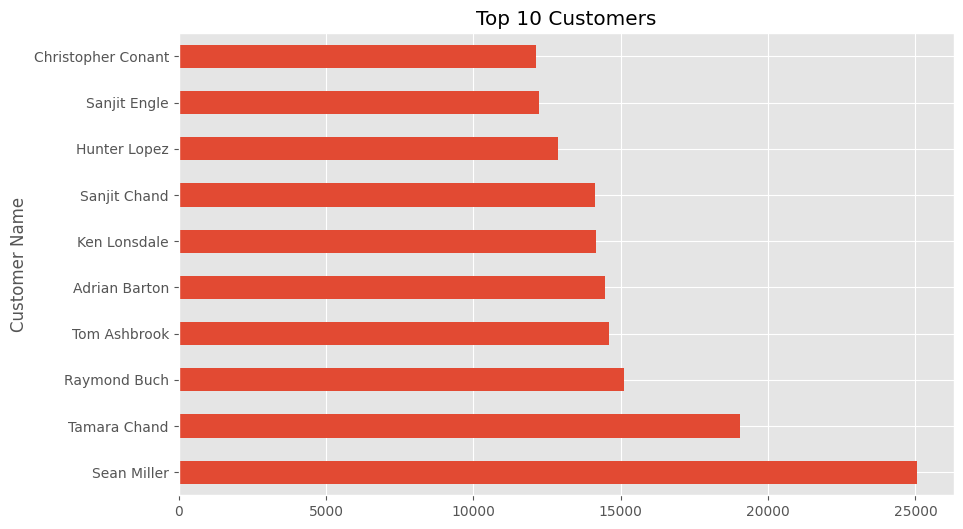

In [26]:
plt.figure(figsize=(10,6))

top_customers.plot(kind="barh")

plt.title("Top 10 Customers")

plt.show()

Analysis 8 — Top 10 Products

In [27]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

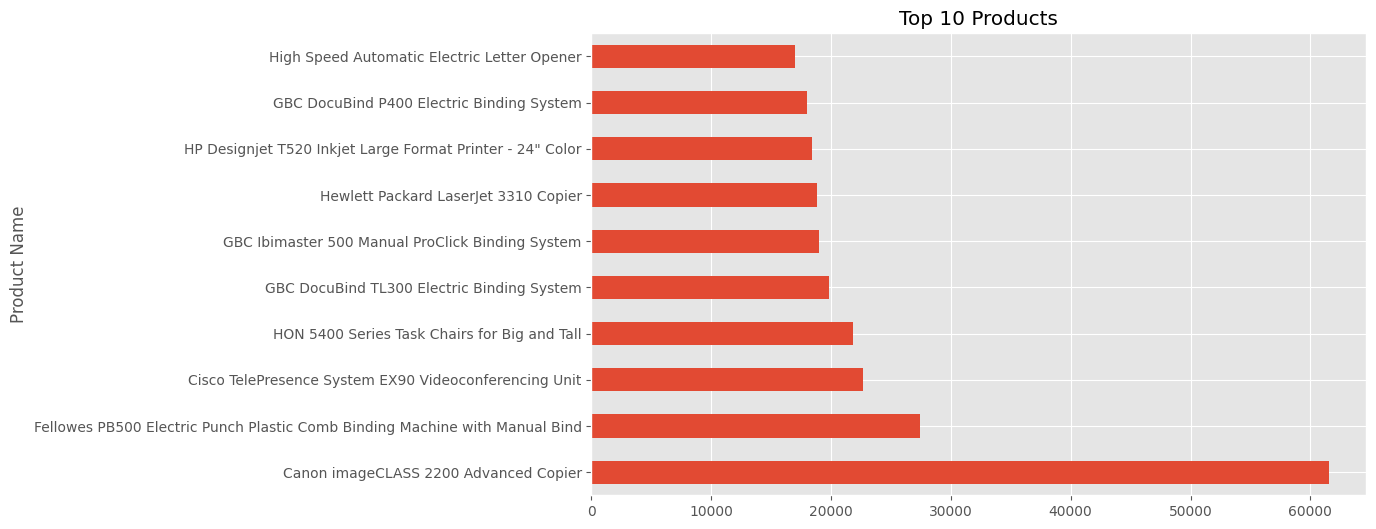

In [28]:
plt.figure(figsize=(10,6))

top_products.plot(kind="barh")

plt.title("Top 10 Products")

plt.show()

Analysis 9 — Top 10 States

In [29]:
top_states = (
    df.groupby("State/Province")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states

State/Province
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

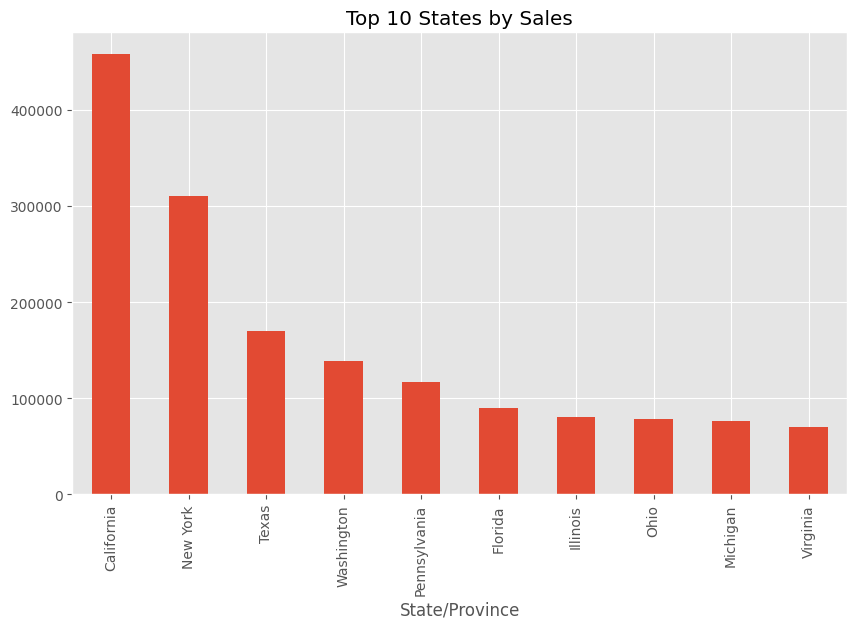

In [30]:
plt.figure(figsize=(10,6))

top_states.plot(kind="bar")

plt.title("Top 10 States by Sales")

plt.show()

Analysis 10 — Discount vs Profit

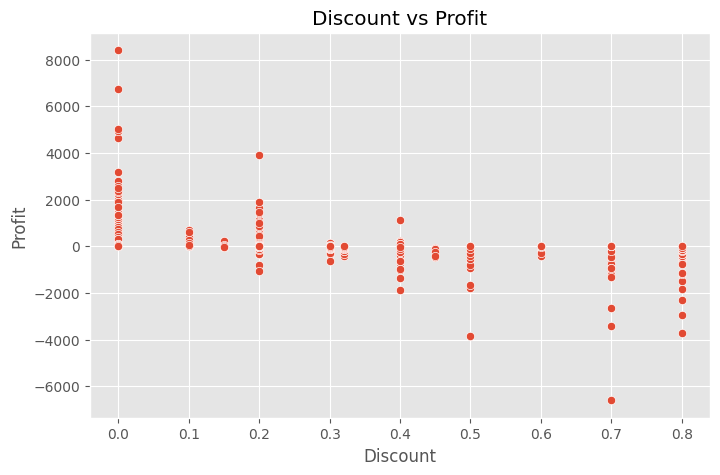

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")

plt.show()

Analysis 11 — Shipping Days Distribution

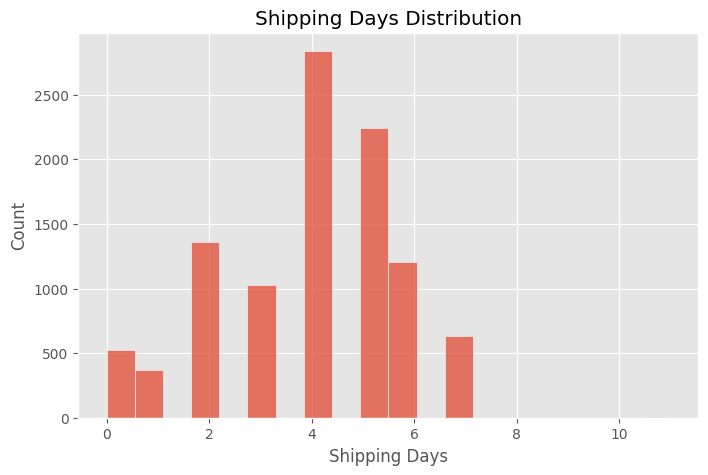

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Shipping Days"],
    bins=20
)

plt.title("Shipping Days Distribution")

plt.show()

Analysis 12 — Correlation Heatmap

In [33]:
numeric_df = df.select_dtypes(include=np.number)

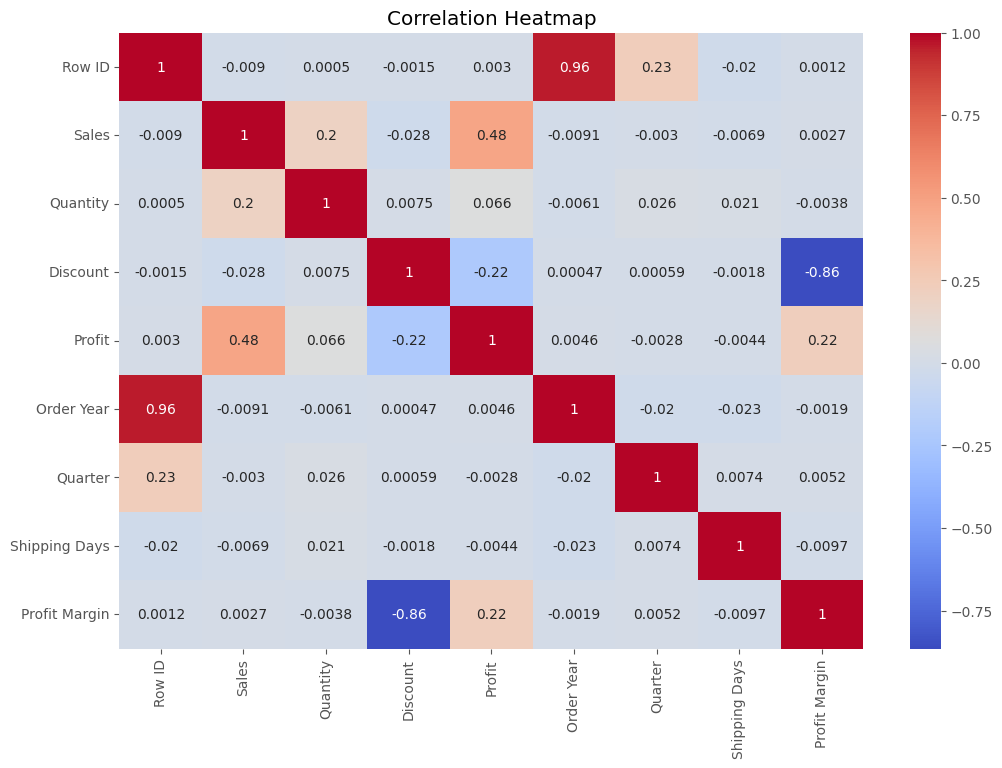

In [34]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Analysis 13 — Profit Margin Distribution

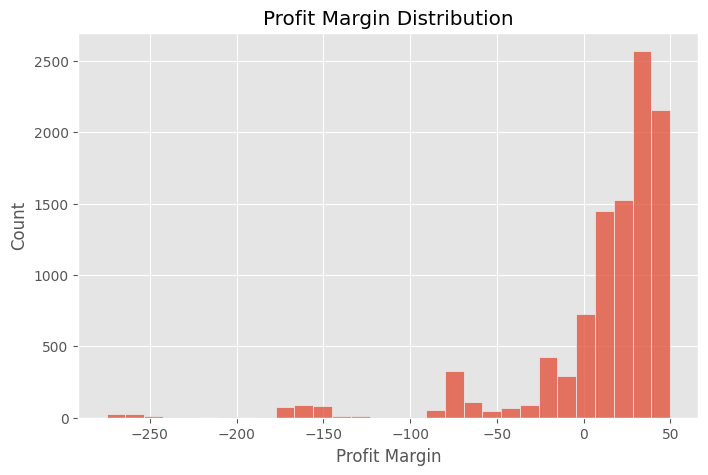

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Profit Margin"],
    bins=30
)

plt.title("Profit Margin Distribution")

plt.show()

In [37]:
import os

os.makedirs("../exports", exist_ok=True)

In [38]:
insights = """
1. Highest Revenue Category:
2. Highest Profit Category:
3. Best Performing Region:
4. Best Customer Segment:
5. Peak Sales Month:
6. Top Customer:
7. Top Product:
8. Discount Impact on Profit:
9. Average Shipping Performance:
10. Sales and Profit show positive correlation.
"""

with open("../exports/eda_insights.txt", "w") as f:
    f.write(insights)

print("EDA Insights Saved Successfully")

EDA Insights Saved Successfully
